Thinking...
Thinking...
thinking...

File metadata:
  Job: Seis
  Sample Rate: 1651.6129032258063
  Start Time: Sun Apr 05 2026 16:53:21 GMT-0700 (Pacific Daylight Time)
Index(['Sample', 'Time (s)', 'Noise', 'East', 'North', 'Zed', 'blank'], dtype='object')

File metadata:
  Job: Seis
  Sample Rate: 1651.6129032258063
  Start Time: Sun Apr 05 2026 17:32:21 GMT-0700 (Pacific Daylight Time)
Index(['Sample', 'Time (s)', 'Noise', 'East', 'North', 'Zed', 'blank'], dtype='object')

File metadata:
  Job: Seis
  Sample Rate: 1651.6129032258063
  Start Time: Sun Apr 05 2026 18:41:23 GMT-0700 (Pacific Daylight Time)
Index(['Sample', 'Time (s)', 'Noise', 'East', 'North', 'Zed', 'blank'], dtype='object')

File metadata:
  Job: Seis
  Sample Rate: 1651.6129032258063
  Start Time: Sun Apr 05 2026 19:21:58 GMT-0700 (Pacific Daylight Time)
Index(['Sample', 'Time (s)', 'Noise', 'East', 'North', 'Zed', 'blank'], dtype='object')

File metadata:
  Job: Seis
  Sample Rate: 1651.6129032258063
  Start Time: 

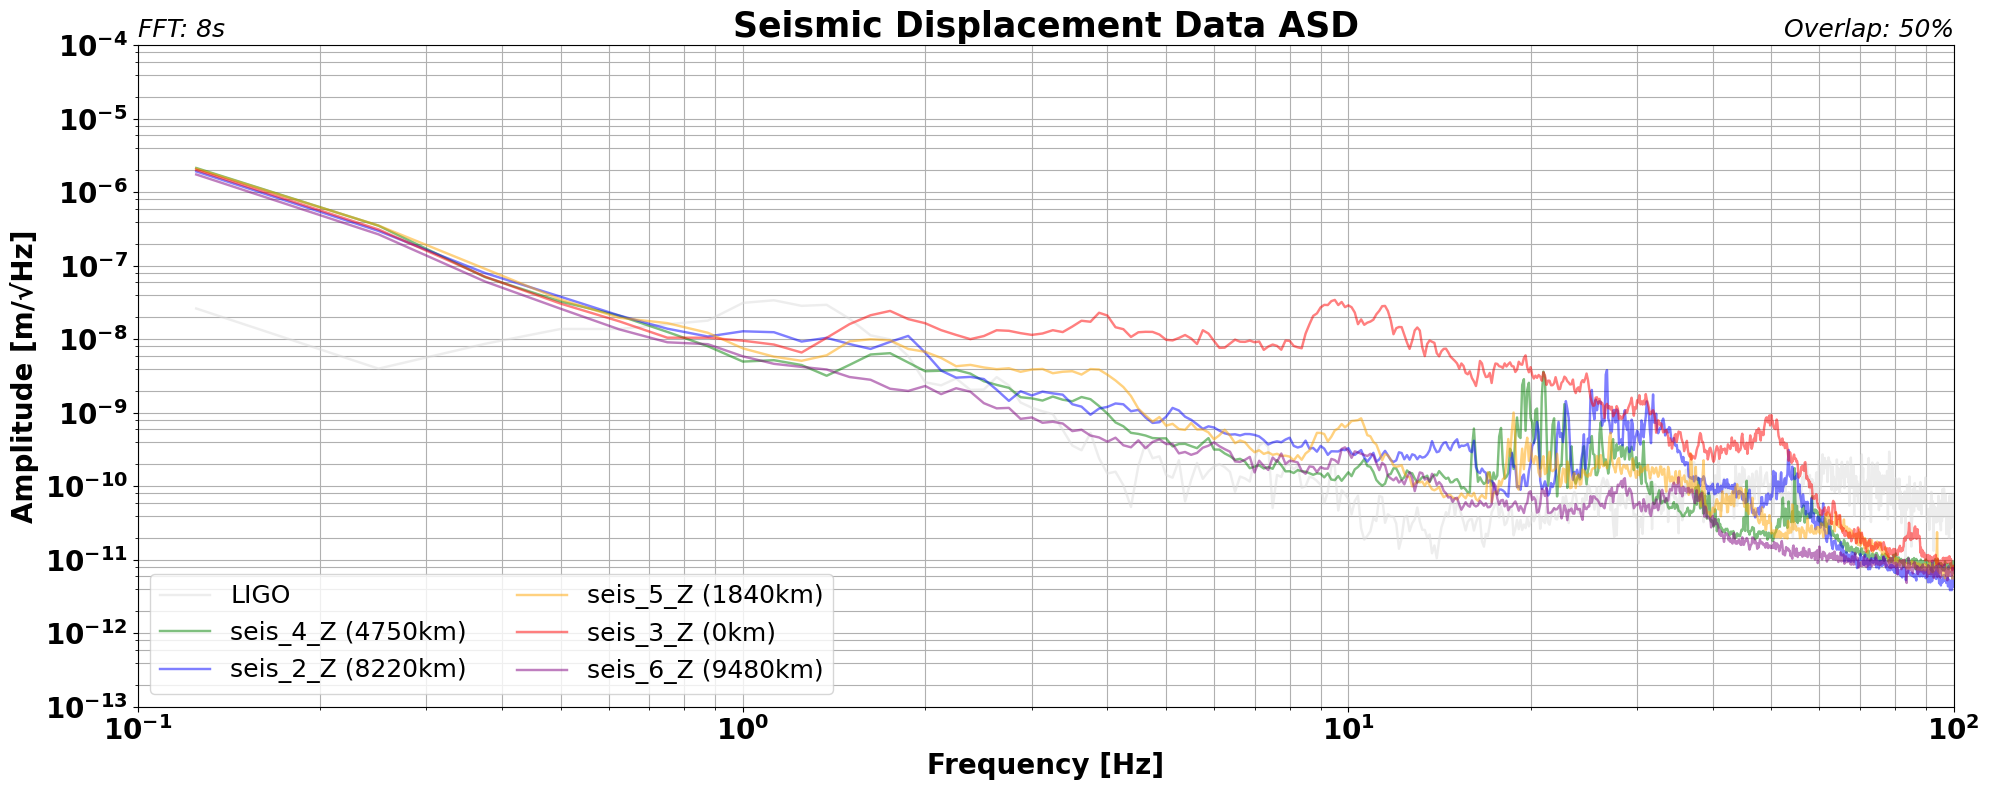

In [28]:
print("Thinking...")
import warnings
import pandas as pd                    # For reading CSV files into tables
import numpy as np                     # For numerical calculations
print("Thinking...")
from scipy import signal               # For the Welch PSD / spectral analysis
from matplotlib import pyplot as plt   # For creating plots
import matplotlib.ticker as ticker
import os

warnings.simplefilter('ignore')

###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------- SECTION 1 — FILE PATH --------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


## Set this to the location of your seismic CSV data file.

filepath = []
#filepath.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\LHOSeismic.txt")
filepath.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis05-clean-harb-close-noactivity-NS-along-road_2026-04-05T23-53-21-314.csv")
filepath.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis07-close-i80-NS-to-i80_2026-04-06T00-32-21-479.csv")
filepath.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis08-Gypsonite-Junction-NS-I80_2026-04-06T01-41-23-216.csv")
filepath.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis10-15POLES-NS-to-i80_2026-04-06T02-21-58-225.csv")
filepath.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis13-CleanHarbor-closer-NS-to-i80_2026-04-06T03-18-25-309.csv")


control_data_path = r"C:\Users\shrey\OneDrive\Desktop\LIGO\LHOSeismic.txt"
huddle = pd.read_csv(control_data_path, delimiter="\s+")
huddle.columns = ["time", "x", "y", "z"]

#ctrl_time = huddle["time"]
print("thinking...")

ctrl_x = huddle["x"] * 1e-9
ctrl_y = huddle["y"] * 1e-9
ctrl_z = huddle["z"] * 1e-9
ctrl_sr = 256



###--------------------------------------------------------------------------------------------------------------------------###
'''----------------------------------------------- SECTION 2 — PLOT SETTINGS ------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


## Adjust these to control how the output plots look and how the FFT is computed.


# Y-axis (amplitude) range in m/√Hz or m·s⁻¹/√Hz:
y_max = 10e-5                                            # Top of the plot    (higher = more noise visible)
y_min = 10e-14                                           # Bottom of the plot (lower = more detail at quiet levels)


# X-axis (frequency) range in Hz:
x_max = 100                                              # Highest frequency to show
x_min = 0.1                                              # Lowest frequency to show


# FFT (spectral analysis) settings:
fft_length = 8                                           # Length of each FFT window in seconds
                                                         #   Longer = better frequency resolution, less time averaging

overlap    = 50                                          # Overlap between consecutive FFT windows, in percent (0–99)


# Were the pre-amplifiers used during recording?
pre_amps = False                                         # Set to True if pre-amps were active


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------ SECTION 4 — READ THE FIELD DATA FILE ------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###
metadata_list = []
raw_data_list = []

for i in np.arange(len(filepath)):
    # --- Read metadata (first 5 lines) ---
    
    metadata = {}
    with open(filepath[i], 'r') as f:
        for _ in range(5):
            line = f.readline().strip()
            if ':' in line:
                key, value = line.split(':', 1)
                metadata[key.strip()] = value.strip()
    
    print("\nFile metadata:")
    for key, value in metadata.items():
        print(f"  {key}: {value}")
    
    sr = float(metadata["Sample Rate"])

    metadata_list.append(metadata)
    
    # --- Read the seismic data columns ---
    raw_data = pd.read_csv(filepath[i], skiprows=5, delimiter=',')
    raw_data.columns = ["Sample", "Time (s)", 
                        "Noise", "East", 
                        "North", "Zed", "blank"]
    print(raw_data.columns)
    raw_data_list.append(raw_data)
    


# --- Apply calibration factor (Volts → meters per second) ---
if pre_amps:
    calibration = (0.0125e-1) / 21
else:
    calibration = 0.0125e-1

seis_1_Z = raw_data_list[0]["Zed"] * calibration
seis_2_Z = raw_data_list[1]["Zed"] * calibration
seis_3_Z = raw_data_list[2]["Zed"] * calibration
seis_4_Z = raw_data_list[3]["Zed"] * calibration
seis_5_Z = raw_data_list[4]["Zed"] * calibration
#seis_6_Z = raw_data_list[5]["Zed"] * calibration

# seis_datas = []

# seis_3_n_1   = []
# seis_3_z_1   = []
# seis_40_n_1   = []
# seis_40_z_1   = [] 

# seis_3_n_2   = []
# seis_3_z_2   = [] 
# seis_40_n_2   = [] 
# seis_40_z_2   = []

# seis_3_n_3   = []
# seis_3_z_3   = []
# seis_40_n_3   = []
# seis_40_z_3   = []


# seis_3_n_1.append(raw_data_list[0]["Seis_3 N_0"] * calibration)   # 
# seis_3_z_1.append(raw_data_list[0]["Seis_3 Z_0"] * calibration)   # 
# seis_40_n_1.append(raw_data_list[0]["Seis_40 N_0"] * calibration)   # 
# seis_40_z_1.append(raw_data_list[0]["Seis_40 Z_0"] * calibration)   # 

# seis_3_n_2.append(raw_data_list[1]["Seis_3 N_1"] * calibration)   # 
# seis_3_z_2.append(raw_data_list[1]["Seis_3 Z_1"] * calibration)   # 
# seis_40_n_2.append(raw_data_list[1]["Seis_40 N_1"] * calibration)   # 
# seis_40_z_2.append(raw_data_list[1]["Seis_40 Z_1"] * calibration)   # 

# seis_3_n_3.append(raw_data_list[2]["Seis_3 N_2"] * calibration)   # 
# seis_3_z_3.append(raw_data_list[2]["Seis_3 Z_2"] * calibration)   # 
# seis_40_n_3.append(raw_data_list[2]["Seis_40 N_2"] * calibration)   # 
# seis_40_z_3.append(raw_data_list[2]["Seis_40 Z_2"] * calibration)   # 


# seis_datas.append(seis_3_n_1)
# seis_datas.append(seis_3_z_1)
# seis_datas.append(seis_40_n_1)
# seis_datas.append(seis_40_z_1)

# seis_datas.append(seis_3_n_2)
# seis_datas.append(seis_3_z_2)
# seis_datas.append(seis_40_n_2)
# seis_datas.append(seis_40_z_2)

# seis_datas.append(seis_3_n_3)
# seis_datas.append(seis_3_z_3)
# seis_datas.append(seis_40_n_3)
# seis_datas.append(seis_40_z_3)



# start_time = 0
# mid_time = 150
# end_time = 300

# start = int(start_time * sr)
# if start < 0:
#     start = 0
# end = int(end_time * sr)
# mid = int(mid_time * sr)

# for i in seis_datas:
#     A = i[0][start:mid]
#     i.append(A)
#     B = i[0][mid:end]
#     i.append(B)
    


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------- SECTION 6 — AXIS LABELS AND TITLES -------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


plot_title_velocity     = "Seismic Velocity Data ASD"
plot_title_displacement = "Seismic Displacement Data ASD"
plot_titles             = {'z': "Run 1",
                           'n': "Run 2",
                           'e': "Run 3"}

channel_titles_1        = {'z': "LIGO",
                           'n': "seis_2_Z (8220km)",
                           'e': "seis_3_Z (0km)"}

channel_titles_2        = {'z': "seis_4_Z (4750km)",
                           'n': "seis_5_Z (1840km)",
                           'e': "seis_6_Z (9480km)"}

ylabel_velocity         = "Amplitude [ms⁻¹/√Hz]"
ylabel_displacement     = "Amplitude [m/√Hz]"


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------ SECTION 7 — ASD CALCULATION AND PLOTTING FUNCTION -----------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


# Arguments:
#   data_vertical, data_north, data_east  — field data arrays (pass None to skip)
#   field_sample_rate                     — samples per second for field data
#   fft_window_s                          — FFT window length in seconds
#   y_min, y_max                          — amplitude axis limits
#   x_min, x_max                          — frequency axis limits
#   plot_type                             — 'velocity' or 'displacement'
#   channel                               — 'all', 'east', 'north', or 'zed'


def compute_and_plot_asd(seis1_z, seis1_n, seis1_e, seis2_z, seis2_n, seis2_e, field_sample_rate, 
                         overlap, fft_window_s, y_min, y_max, x_min, x_max, plot_type, channel):
    
    
    # ------------------- Inner helper: compute ASD for a single data array ---------------------- #
    
    def welch_asd(data, sr):
        """
        Run Welch's method on `data` sampled at `sr` Hz.
        Returns (frequencies, amplitude_spectral_density).
        """
        data = np.asarray(data)   # Ensure it's a plain numpy array

        frequencies, power = signal.welch(
            data,
            sr,
            window   = 'hamming',
            nperseg  = int(sr * fft_window_s),                  ## nperseg:  number of samples per FFT window
            noverlap = int(round(sr * (overlap * 0.01) ) )      ## noverlap: number of samples shared between adjacent windows
        )
        
        # ASD = square root of PSD
        return frequencies, np.sqrt(power)

    # -------------------------- Map channel keys to their data arrays --------------------------- #
    
    seis_1_channels = {'z': seis1_z,
                       'n': seis1_n,
                       'e': seis1_e}

    seis_2_channels = {'z': seis2_z,
                       'n': seis2_n,
                       'e': seis2_e}

    # ------------------------------------- Compute field ASDs ----------------------------------- #
    
    seis_1_results = {}

    for key, data in seis_1_channels.items():
        if data is None:
            continue   # Skip channels that weren't passed in

        freq, amp = welch_asd(data, field_sample_rate)

        if plot_type == 'displacement':
            
            # Convert velocity ASD → displacement ASD: divide by 2πf
            # (integrating in frequency domain)
            # Avoid division by zero at DC (freq = 0 Hz): set that bin to NaN
            
            disp = np.where(freq > 0, amp / (2 * np.pi * freq), np.nan)
        else:
            disp = None

        seis_1_results[key] = {'frequency': freq,
                               'amp':       amp,
                               'disp':      disp}

    # -------------------------------- Compute LIGO reference ASDs ------------------------------- #
    
    seis_2_results = {}

    for key, data in seis_2_channels.items():
        if data is None:
            continue

        freq, amp = welch_asd(data, field_sample_rate)

        if plot_type == 'displacement':
            disp = np.where(freq > 0, amp / (2 * np.pi * freq), np.nan)
        else:
            disp = None

        seis_2_results[key] = {'frequency': freq,
                               'amp':       amp,
                               'disp':      disp}

    # ------------------------ Decide which channels to include in this plot ---------------------- #
    
    
    channel_name_to_key = {'east':  'e',
                           'north':  'n',
                           'zed':    'z'}

    if channel == 'all':
        channels_to_plot = ['z', 'n', 'e']
        plot_title = plot_title_velocity if plot_type == 'velocity' else plot_title_displacement
        
    else:
        key = channel_name_to_key[channel]
        channels_to_plot = [key]
        plot_title = plot_titles[key]
        

    # ---------------------------------- Color coding per channel --------------------------------- #
    
    line_colors_1 = {'z': 'gainsboro',
                     'n': 'blue',
                     'e': 'red'}
    
    line_colors_2 = {'z': 'green',
                     'n': 'orange',
                     'e': 'purple'}

    
    # --------------------------- Select y-axis label based on plot type -------------------------- #
    
    ylabel = ylabel_velocity if plot_type == 'velocity' else ylabel_displacement

    
    # ---------------------------------------- Draw the plot -------------------------------------- #
    
    plt.figure(figsize = (20, 8))
    plt.yscale('log')
    plt.xscale('log')

    for ch in channels_to_plot:
        if ch not in seis_1_results:
            continue

        # Choose velocity or displacement data for y-axis
        if plot_type == 'velocity':
            y_seis_1  = seis_1_results[ch]['amp']
            y_seis_2  = seis_2_results[ch]['amp']
        else:
            y_seis_1  = seis_1_results[ch]['disp']
            y_seis_2  = seis_2_results[ch]['disp']

        f_seis_1  = seis_1_results[ch]['frequency']
        f_seis_2  = seis_2_results[ch]['frequency']

        # Seis 1 data — solid line, channel color
        plt.plot(f_seis_1, y_seis_1,
                 color     = line_colors_1[ch],
                 linewidth = 1.75,
                 alpha     = 0.5,
                 label     = channel_titles_1[ch])

        # Seis 2 data — grey, semi-transparent
        plt.plot(f_seis_2, y_seis_2,
                 color     = line_colors_2[ch],
                 linewidth = 1.75,
                 alpha     = 0.5,
                 label     = channel_titles_2[ch])

    # --------------------------------------- Axis formatting ------------------------------------- #
    
    ax = plt.gca()
    ax.minorticks_on()

    
    plt.title(plot_title, fontweight = 'bold', fontsize = 25)
    plt.title(f'FFT: {fft_window_s}s', fontsize = 18, loc = 'left', style = 'italic')
    plt.title(f'Overlap: {overlap}%', fontsize = 18, loc = 'right', style = 'italic')

    plt.xlabel('Frequency [Hz]', fontweight = 'bold', fontsize = 20)
    plt.ylabel(ylabel,           fontweight = 'bold', fontsize = 20)
    
    plt.yticks(fontsize = 20, fontweight = 'bold')
    plt.xticks(fontsize = 20, fontweight = 'bold')

    
    ax.tick_params(axis = 'both', which = 'minor', labelsize = 16)
    for label in ax.get_yticklabels(which = 'minor'):
        label.set_fontweight('bold')
    for label in ax.get_xticklabels(which = 'minor'):
        label.set_fontweight('bold')

    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=(0.2, 0.4, 0.6, 0.8), numticks=20))
    #ax.yaxis.set_minor_formatter(ticker.LogFormatterMathtext())

    plt.ylim(y_min, y_max)
    plt.xlim(x_min, x_max)

    plt.legend(loc = 'lower left', fontsize = 18, ncol = 2)
    plt.grid(True, which = 'both', ls = '-')
    plt.tight_layout()
    plt.savefig("test.png")
    plt.show()


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------ SECTION 8 — RUN THE PLOTS -----------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###

# Shared keyword arguments to avoid repeating them three times
common_args = dict(
    field_sample_rate = sr,
    overlap           = overlap,
    fft_window_s      = fft_length,
    y_min             = y_min,
    y_max             = y_max,
    x_min             = x_min,
    x_max             = x_max,
    plot_type         = "displacement"
)
'''
# ── All Channels (combined plot) — uncomment to enable ────────────────────────
compute_and_plot_asd(None, seis_1_n, , seis_2_n,seis_2_e
                     channel='all', **common_args)
'''


# ── North / East Channel ──────────────────────────────────────────────────────
compute_and_plot_asd(ctrl_z, seis_1_Z, seis_2_Z,seis_3_Z, seis_4_Z, seis_5_Z,
                     channel = 'all', **common_args)

# ── Vertical (Z) Channel ──────────────────────────────────────────────────────
#compute_and_plot_asd(seis_1_z, None, None, seis_2_z, None, None,
#                     channel = 'zed', **common_args)